In [63]:
import numpy as np
import cv2 as cv

import matplotlib.pyplot as plt

import rembg

from os.path import dirname, join, abspath

## Version REMBG

In [64]:
BASE_DIR = 'Samples'

input_path  = join(BASE_DIR, '01_Samples', '00_state', '01_raton.jpeg')
output_path = join(BASE_DIR, '01_Samples', '01_state', '01_raton.png')

input_img = cv.imread(input_path)
output_img = rembg.remove(input_img) # Hace magia con IA

cv.imwrite(output_path, output_img)


True

## Versión Propia

In [ ]:
def clean_image(img_color, threshold_value=140, se_size=(55, 55)):
    """
    Limpia una imagen a color de su fondo mediante umbralización y operaciones morfológicas.
    
    Args:
        img_color: Imagen en color (BGR)
        threshold_value: Valor de umbral para binarización (default: 140)
        se_size: Tamaño del elemento estructurante (default: (35, 35))
    
    Returns:
        Imagen limpia con canal alfa (BGRA)
    """
    img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

    img_gray = cv.medianBlur(img_gray, 5)

    _, bin = cv.threshold(img_gray, threshold_value, 255, cv.THRESH_BINARY)

    bin_open = cv.dilate(bin, cv.getStructuringElement(cv.MORPH_CROSS, se_size))

    # Crear imagen BGRA con canal alfa
    img_bgra = cv.cvtColor(img_color, cv.COLOR_BGR2BGRA)
    img_bgra[:, :, 3] = bin_open  # Asignar la máscara al canal alfa
    
    return img_bgra

### Test con el ejemplo 01, el ratón

Procesando imagen 0...
Procesando imagen 1...
Procesando imagen 2...
Procesando imagen 3...
Procesando imagen 4...
Procesando imagen 5...
Procesando imagen 6...
Procesando imagen 7...
Procesando imagen 8...
Procesando imagen 9...
Procesando imagen 10...


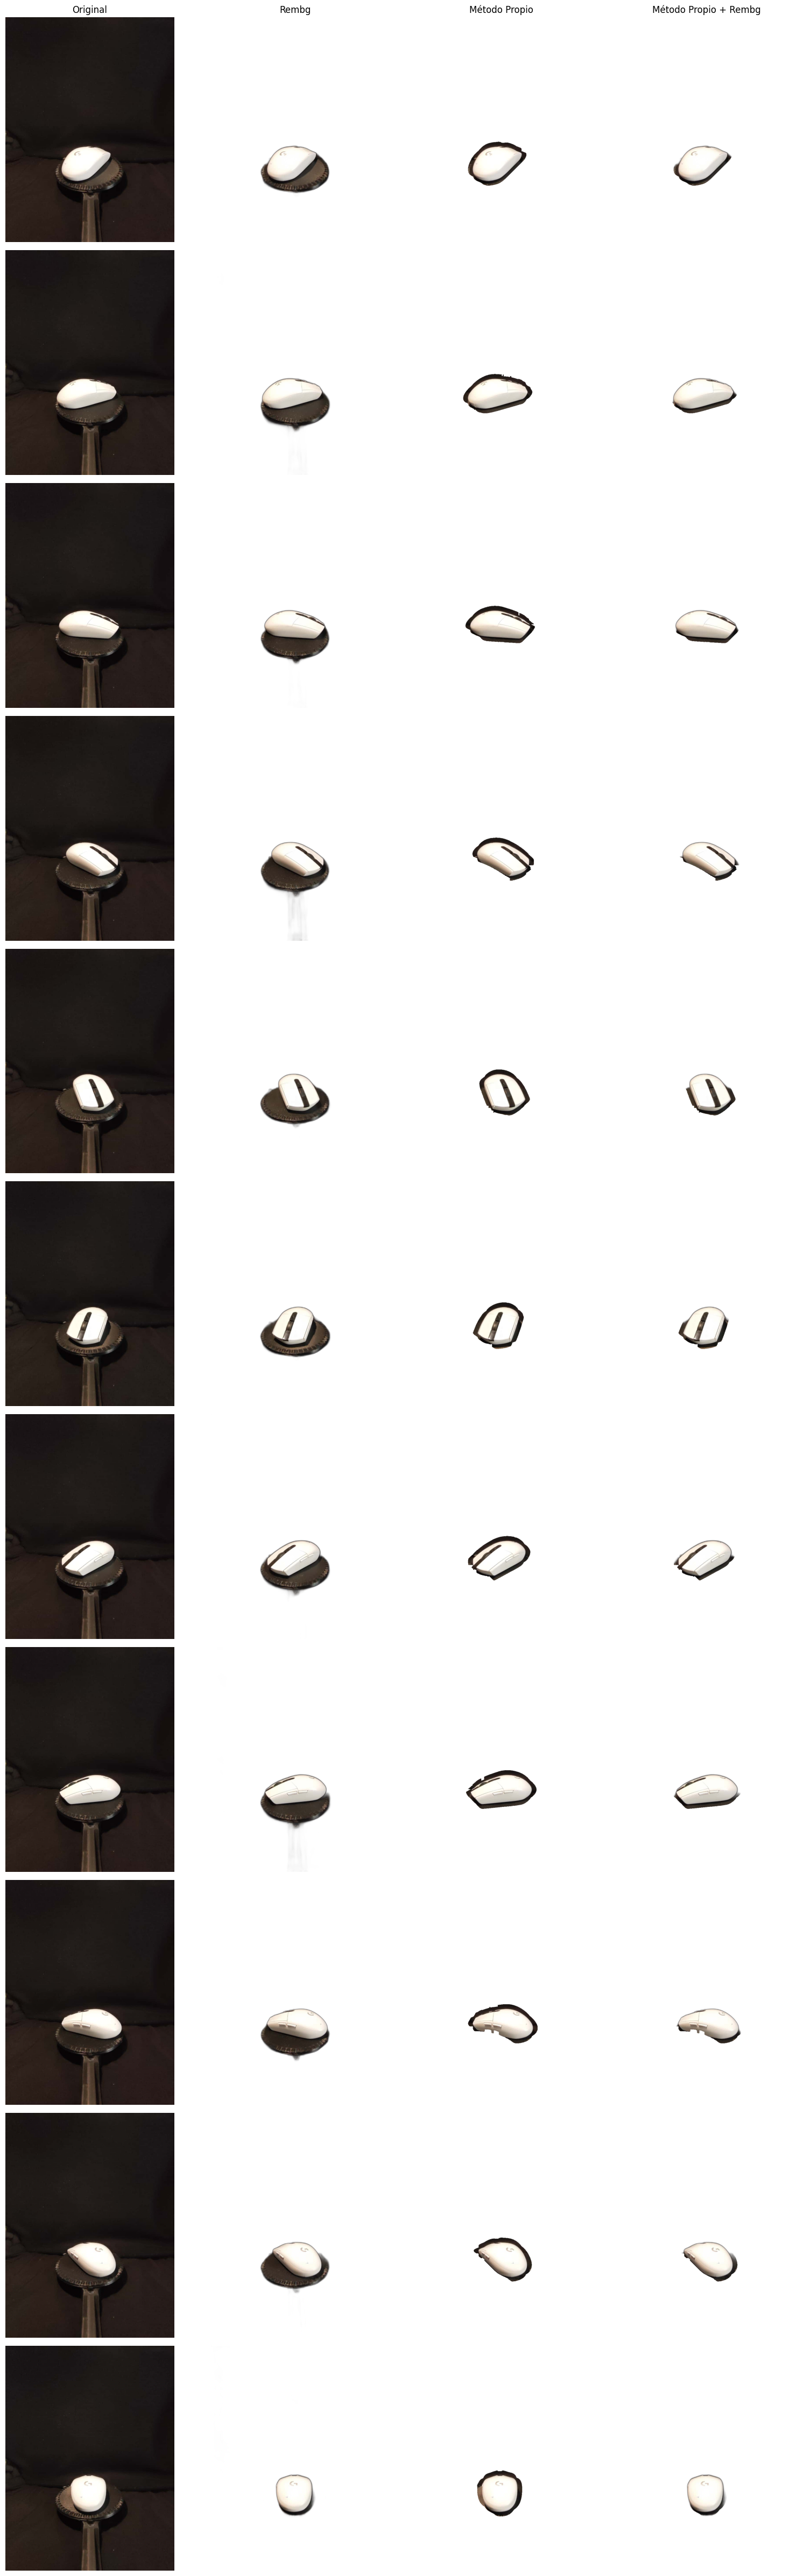

In [68]:
# Leer las 3 primeras imágenes del ratón
img_paths = [
    join(BASE_DIR, '01_Samples', '00_state', f'{i:02d}_raton.jpeg')
    for i in range(1, 12)
]

imgs_original = [cv.imread(path) for path in img_paths]

# Procesar las imágenes
imgs_rembg = [rembg.remove(img) for img in imgs_original]
imgs_custom = [clean_image(img) for img in imgs_original]
imgs_custom_rembg = [rembg.remove(img) for img in imgs_custom]

# Crear la grid de visualización
fig, axes = plt.subplots(11, 4, figsize=(16, 48))

titles = ['Original', 'Rembg', 'Método Propio', 'Método Propio + Rembg']

for row in range(11):
    print(f'Procesando imagen {row}...')
    # Original
    axes[row, 0].imshow(cv.cvtColor(imgs_original[row], cv.COLOR_BGR2RGB))
    axes[row, 0].axis('off')
    if row == 0:
        axes[row, 0].set_title(titles[0])
    
    # Rembg
    axes[row, 1].imshow(cv.cvtColor(imgs_rembg[row], cv.COLOR_BGRA2RGBA))
    axes[row, 1].axis('off')
    if row == 0:
        axes[row, 1].set_title(titles[1])
    
    # Método propio
    axes[row, 2].imshow(cv.cvtColor(imgs_custom[row], cv.COLOR_BGRA2RGBA))
    axes[row, 2].axis('off')
    if row == 0:
        axes[row, 2].set_title(titles[2])
    
    # Método propio + Rembg
    axes[row, 3].imshow(cv.cvtColor(imgs_custom_rembg[row], cv.COLOR_BGRA2RGBA))
    axes[row, 3].axis('off')
    if row == 0:
        axes[row, 3].set_title(titles[3])

plt.tight_layout()
plt.show()

In [ ]:
imgs_clean = []
for i in range(11):

  img_blur = cv.medianBlur(img_gray[i], 5)

  _, bin = cv.threshold(img_blur, 140, 255, cv.THRESH_BINARY)

  SE = cv.getStructuringElement(cv.MORPH_ELLIPSE, (35,35))
  bin_open = cv.dilate(bin, SE)

  clean = cv.bitwise_and(img_color[i],img_color[i], mask=bin_open)
  imgs_clean.append(clean)
  cv.imwrite('raton_clean'+str(i)+'.jpg', clean)

In [ ]:
def feature_and_matching_knn_test(im1, im2):
  #Buscamos los puntos característicos con sus descriptores con el SIFT
  sift = cv.SIFT_create()
  kp1, des1 = sift.detectAndCompute(im1, None)
  kp2, des2 = sift.detectAndCompute(im2, None)
  #Buscamos una asicoación entre los puntos de las dos imágenes, usaremos el de fuerza bruta BFMatcher
  bf = cv.BFMatcher()

  matches = bf.knnMatch(des1, des2, k=2)
  #Escogemos sólo las asociaciones de puntos cercanos
  good_matches = []
  for m, n in matches:
    if m.distance <  n.distance*0.7:
      good_matches.append(m)

  #Medimos rendimiento
  img_matched = cv.drawMatchesKnn(im1, kp1, im2, kp2, good_matches, None, matchColor=(0, 255, 0),
                       singlePointColor=(0, 255, 0), flags=2)
  plt.imshow(img_matched)
  plt.axis('off')
  print(f"Puntos encontrados img1: {len(kp1)}")
  print(f"Puntos encontrados img2: {len(kp2)}")
  print(f"Buenos emparejamientos (Matches): {len(good_matches)}")


In [ ]:
def feature_and_matching(im1, im2):
  #Buscamos los puntos característicos con sus descriptores con el SIFT
  sift = cv.SIFT_create()
  kp1, des1 = sift.detectAndCompute(im1, None)
  kp2, des2 = sift.detectAndCompute(im2, None)
  #Buscamos una asicoación entre los puntos de las dos imágenes, usaremos el de fuerza bruta BFMatcher
  bf = cv.BFMatcher()

  matches = bf.match(des1, des2)
  #Escogemos sólo las asociaciones de puntos cercanos
  '''  
  matches = bf.knnmatch(des1, des2)
  good_matches = []
  pts1 = []
  pts2 = []
  for m, n in matches:
    if m.distance <  n.distance*0.7:
      good_matches.append(m)
      pts1.append(kp1[m.queryIdx].pt)
      pts2.append(kp2[m.trainIdx].pt)
  '''
  return (kp1, kp2[[p.trainIdx for p in matches]])


Caso 0,1
Puntos encontrados img1: 51
Puntos encontrados img2: 47
Buenos emparejamientos (Matches): 9
Caso 1,2
Puntos encontrados img1: 47
Puntos encontrados img2: 57
Buenos emparejamientos (Matches): 5
Caso 2,3
Puntos encontrados img1: 57
Puntos encontrados img2: 51
Buenos emparejamientos (Matches): 3
Caso 3,4
Puntos encontrados img1: 51
Puntos encontrados img2: 57
Buenos emparejamientos (Matches): 3
Caso 4,5
Puntos encontrados img1: 57
Puntos encontrados img2: 68
Buenos emparejamientos (Matches): 4
Caso 5,6
Puntos encontrados img1: 68
Puntos encontrados img2: 82
Buenos emparejamientos (Matches): 5
Caso 6,7
Puntos encontrados img1: 82
Puntos encontrados img2: 65
Buenos emparejamientos (Matches): 13
Caso 7,8
Puntos encontrados img1: 65
Puntos encontrados img2: 66
Buenos emparejamientos (Matches): 4
Caso 8,9
Puntos encontrados img1: 66
Puntos encontrados img2: 57
Buenos emparejamientos (Matches): 8
Caso 9,10
Puntos encontrados img1: 57
Puntos encontrados img2: 48
Buenos emparejamientos (

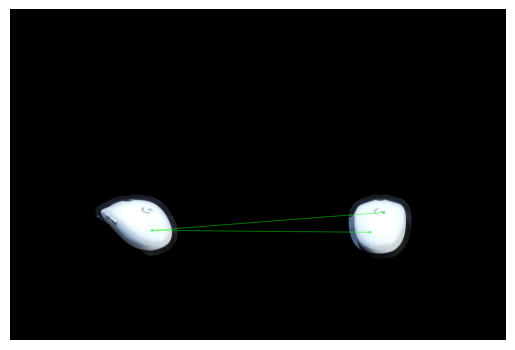

In [ ]:
for i,j in zip(range(10),range(1,11)):
  print(f'Caso {i},{j}')
  feature_and_matching_knn_test(imgs_clean[i], imgs_clean[j])


In [ ]:
def Sfm(pts1, pts2):
    K 

    E, mask = cv.findEssentialMat(pts1, pts2, K, method=cv.RANSAC, prob=0.999, threshold=1.0)